Starting training for 5 models...
Model 1/5 done! Final loss: 1.5781
Model 2/5 done! Final loss: 1.6465
Model 3/5 done! Final loss: 1.6150
Model 4/5 done! Final loss: 1.6592
Model 5/5 done! Final loss: 1.6409


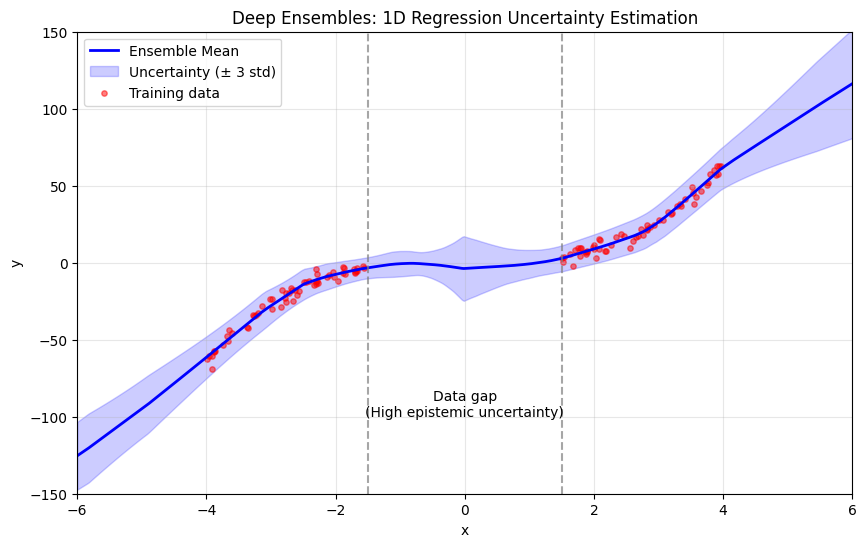

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#Toy dataset generation
#Creating a simple non-linear function (y = x^3 + noise)
#I'm intentionally leaving a gap in the middle of the training data
#to test if the ensemble can output high epistemic uncertainty there.

def generate_data(n_samples=200):
    X_train = np.random.uniform(-4, 4, n_samples)
    # filter out data between -1.5 and 1.5 to create the gap
    X_train = X_train[(X_train < -1.5)|(X_train > 1.5)]
    noise = np.random.normal(0,3.0,len(X_train))
    y_train = (X_train ** 3) +noise
    #Cast to PyTorch tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    return X_train_t, y_train_t, X_train, y_train

X_train_t, y_train_t, X_train, y_train = generate_data()

# test data covering the whole range, including the gap
X_test = np.linspace(-6, 6,400)
X_test_t = torch.tensor(X_test,dtype=torch.float32).unsqueeze(1)


# Model architecture & loss

class ProbabilisticNetwork(nn.Module):
    def __init__(self):
        super(ProbabilisticNetwork, self).__init__()
        #just a basic MLP with 2 hidden layers
        self.fc1 = nn.Linear(1,50)
        self.fc2 = nn.Linear(50,50)
        # output layer has 2 nodes
        self.fc_out = nn.Linear(50, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        out = self.fc_out(x)
        mean = out[:, 0:1]
        #variance must be strictly positive
        #using softplus like in the paper + a tiny epsilon so it never hits exactly 0 (prevents NaNs)
        var = nn.functional.softplus(out[:, 1:2]) + 1e-6
        return mean, var

def gaussian_nll_loss(mean, var, y_true):
    # Custom negative Log-Likelihood loss
    # Formula: 0.5 * log(var) + 0.5 * (y - mean)^2 / var
    loss = 0.5 * torch.log(var) + 0.5 * ((y_true - mean) ** 2) /var
    return loss.mean()


#TRAINING

M_MODELS = 5  # the paper suggests 5
epochs = 1500
learning_rate =0.01

ensembles =[]

print(f"Starting training for {M_MODELS} models...")

for m in range(M_MODELS):
    model = ProbabilisticNetwork()
    optimizer = optim.Adam(model.parameters(),lr=learning_rate)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        mean, var = model(X_train_t)
        loss = gaussian_nll_loss(mean, var, y_train_t)
        loss.backward()
        optimizer.step()
    ensembles.append(model)
    print(f"Model {m+1}/{M_MODELS} done! Final loss: {loss.item():.4f}")


# prediction and aggregation

means = []
vars = []

# get predictions from all trained models
with torch.no_grad():
    for model in ensembles:
        model.eval()
        mean, var = model(X_test_t)
        means.append(mean.numpy())
        vars.append(var.numpy())

means = np.array(means)  # Shape will be (M, N_samples, 1)
vars = np.array(vars)
# Aggregation formulas from section 2.4 of the paper
#ensemble mean is just the average of the means
ensemble_mean = means.mean(axis=0)
#ensemble variance uses the Law of Total Variance
# Total var = mean of variances + variance of means
ensemble_var = (vars +means**2).mean(axis=0) - ensemble_mean**2
ensemble_std = np.sqrt(ensemble_var)


#plotting

plt.figure(figsize=(10, 6))
#plot predicted mean
plt.plot(X_test, ensemble_mean.flatten(), 'b-', label='Ensemble Mean', lw=2)
#plot the uncertainty band
plt.fill_between(
    X_test.flatten(),
    (ensemble_mean - 3 * ensemble_std).flatten(),
    (ensemble_mean + 3 * ensemble_std).flatten(),
    color='blue', alpha=0.2, label='Uncertainty (± 3 std)'
)
#plot the training points
plt.scatter(X_train, y_train, color='red', s=15, alpha=0.5, label='Training data')

#mark the out-of-distribution (OOD) gap to show epistemic uncertainty
plt.axvline(-1.5, color='gray',linestyle='--', alpha=0.7)
plt.axvline(1.5, color='gray',linestyle='--',alpha=0.7)
plt.text(0, -100, "Data gap\n(High epistemic uncertainty)", ha='center', color='black')
plt.title("Deep Ensembles: 1D Regression Uncertainty Estimation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.xlim(-6, 6)
plt.ylim(-150, 150)
plt.grid(True, alpha=0.3)
plt.show()